In [36]:
import time
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

EPOCHS = 5
LEARNING_RATE = 1e-3

def load_image_base(path, label):
    image = tf.io.read_file(path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])

    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)

    return image, tf.cast(label, tf.float32)

print("Setup complete!")
print("GPU:", tf.config.list_physical_devices("GPU"))

Setup complete!
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [37]:
# Base datasets
train_base = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

val_base = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)

test_base = tf.data.Dataset.from_tensor_slices(
    (test_paths, test_labels)
)


# -----------------------------
# ResNet50
# -----------------------------
def preprocess_resnet(path, label):
    image, label = load_image_base(path, label)
    image = tf.keras.applications.resnet50.preprocess_input(image)
    return image, label


# -----------------------------
# MobileNetV2
# -----------------------------
def preprocess_mobilenet(path, label):
    image, label = load_image_base(path, label)
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label


# -----------------------------
# EfficientNetB0
# -----------------------------
def preprocess_efficientnet(path, label):
    image, label = load_image_base(path, label)
    return image, label


# ResNet datasets
train_resnet = train_base.map(
    preprocess_resnet,
    num_parallel_calls=AUTOTUNE
).shuffle(10000, seed=42).batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_resnet = val_base.map(
    preprocess_resnet,
    num_parallel_calls=AUTOTUNE
).batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_resnet = test_base.map(
    preprocess_resnet,
    num_parallel_calls=AUTOTUNE
).batch(BATCH_SIZE).prefetch(AUTOTUNE)


# MobileNet datasets
train_mobilenet = train_base.map(
    preprocess_mobilenet,
    num_parallel_calls=AUTOTUNE
).shuffle(10000, seed=42).batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_mobilenet = val_base.map(
    preprocess_mobilenet,
    num_parallel_calls=AUTOTUNE
).batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_mobilenet = test_base.map(
    preprocess_mobilenet,
    num_parallel_calls=AUTOTUNE
).batch(BATCH_SIZE).prefetch(AUTOTUNE)


# EfficientNet datasets
train_efficientnet = train_base.map(
    preprocess_efficientnet,
    num_parallel_calls=AUTOTUNE
).shuffle(10000, seed=42).batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_efficientnet = val_base.map(
    preprocess_efficientnet,
    num_parallel_calls=AUTOTUNE
).batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_efficientnet = test_base.map(
    preprocess_efficientnet,
    num_parallel_calls=AUTOTUNE
).batch(BATCH_SIZE).prefetch(AUTOTUNE)

print("All 3 preprocessing pipelines ready!")

All 3 preprocessing pipelines ready!


In [40]:
# ==========================================
# BUILD + TRAIN ALL 5 PRETRAINED MODELS
# ==========================================

def build_model(base_model):

    base_model.trainable = False

    inputs = tf.keras.Input(
        shape=(224, 224, 3)
    )

    x = base_model(
        inputs,
        training=False
    )

    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    x = tf.keras.layers.Dense(
        128,
        activation="relu"
    )(x)

    x = tf.keras.layers.Dropout(0.3)(x)

    outputs = tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )(x)

    model = tf.keras.Model(
        inputs,
        outputs
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=LEARNING_RATE
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


# ==========================================
# 1. RESNET50
# ==========================================

print("\n" + "=" * 50)
print("Training ResNet50...")
print("=" * 50)

resnet_model = build_model(
    tf.keras.applications.ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )
)

start = time.time()

history_resnet = resnet_model.fit(
    train_resnet,
    validation_data=val_resnet,
    epochs=EPOCHS
)

resnet_time = (time.time() - start) / 60

print(f"ResNet50 time: {resnet_time:.2f} min")


# ==========================================
# 2. MOBILENETV2
# ==========================================

print("\n" + "=" * 50)
print("Training MobileNetV2...")
print("=" * 50)

mobilenet_model = build_model(
    tf.keras.applications.MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )
)

start = time.time()

history_mobilenet = mobilenet_model.fit(
    train_mobilenet,
    validation_data=val_mobilenet,
    epochs=EPOCHS
)

mobilenet_time = (time.time() - start) / 60

print(f"MobileNetV2 time: {mobilenet_time:.2f} min")


# ==========================================
# 3. EFFICIENTNETB0
# ==========================================

print("\n" + "=" * 50)
print("Training EfficientNetB0...")
print("=" * 50)

efficientnet_model = build_model(
    tf.keras.applications.EfficientNetB0(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )
)

start = time.time()

history_efficientnet = efficientnet_model.fit(
    train_efficientnet,
    validation_data=val_efficientnet,
    epochs=EPOCHS
)

efficientnet_time = (time.time() - start) / 60

print(f"EfficientNetB0 time: {efficientnet_time:.2f} min")


# ==========================================
# 4. DENSENET121
# ==========================================

print("\n" + "=" * 50)
print("Training DenseNet121...")
print("=" * 50)

densenet_model = build_model(
    tf.keras.applications.DenseNet121(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )
)

start = time.time()

history_densenet = densenet_model.fit(
    train_densenet,
    validation_data=val_densenet,
    epochs=EPOCHS
)

densenet_time = (time.time() - start) / 60

print(f"DenseNet121 time: {densenet_time:.2f} min")


# ==========================================
# 5. INCEPTIONV3
# ==========================================

print("\n" + "=" * 50)
print("Training InceptionV3...")
print("=" * 50)

inception_model = build_model(
    tf.keras.applications.InceptionV3(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )
)

start = time.time()

history_inception = inception_model.fit(
    train_inception,
    validation_data=val_inception,
    epochs=EPOCHS
)

inception_time = (time.time() - start) / 60

print(f"InceptionV3 time: {inception_time:.2f} min")


# ==========================================
# COMPLETE
# ==========================================

print("\n" + "=" * 60)
print("ALL 5 MODELS TRAINED SUCCESSFULLY!")
print("=" * 60)

print(f"ResNet50       : {resnet_time:.2f} min")
print(f"MobileNetV2    : {mobilenet_time:.2f} min")
print(f"EfficientNetB0 : {efficientnet_time:.2f} min")
print(f"DenseNet121    : {densenet_time:.2f} min")
print(f"InceptionV3    : {inception_time:.2f} min")


Training ResNet50...
Epoch 1/5
893/893 ━━━━━━━━━━━━━━━━━━━━ 190s 152ms/step - accuracy: 0.9959 - loss: 0.0122 - val_accuracy: 0.9997 - val_loss: 0.0037
Epoch 2/5
893/893 ━━━━━━━━━━━━━━━━━━━━ 169s 140ms/step - accuracy: 0.9985 - loss: 0.0046 - val_accuracy: 0.9992 - val_loss: 0.0071
Epoch 3/5
893/893 ━━━━━━━━━━━━━━━━━━━━ 167s 140ms/step - accuracy: 0.9989 - loss: 0.0042 - val_accuracy: 0.9986 - val_loss: 0.0066
Epoch 4/5
893/893 ━━━━━━━━━━━━━━━━━━━━ 167s 141ms/step - accuracy: 0.9998 - loss: 6.5554e-04 - val_accuracy: 0.9994 - val_loss: 0.0062
Epoch 5/5
893/893 ━━━━━━━━━━━━━━━━━━━━ 165s 140ms/step - accuracy: 0.9991 - loss: 0.0035 - val_accuracy: 0.9989 - val_loss: 0.0106
ResNet50 time: 14.29 min

Training MobileNetV2...
Epoch 1/5
893/893 ━━━━━━━━━━━━━━━━━━━━ 152s 116ms/step - accuracy: 0.9938 - loss: 0.0162 - val_accuracy: 0.9947 - val_loss: 0.0129
Epoch 2/5
893/893 ━━━━━━━━━━━━━━━━━━━━ 130s 102ms/step - accuracy: 0.9988 - loss: 0.0040 - val_accuracy: 0.9966 - val_loss: 0.0202
Epoch 3

NameError: name 'train_densenet' is not defined

In [45]:
# ==========================================
# DENSENET121 DATASETS
# ==========================================

def preprocess_densenet(path, label):
    image, label = load_image_base(path, label)

    image = tf.keras.applications.densenet.preprocess_input(
        image
    )

    return image, label


train_densenet = (
    train_base
    .map(preprocess_densenet, num_parallel_calls=AUTOTUNE)
    .shuffle(10000, seed=42)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_densenet = (
    val_base
    .map(preprocess_densenet, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_densenet = (
    test_base
    .map(preprocess_densenet, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
print("DenseNet121 datasets ready!")

DenseNet121 datasets ready!


In [46]:
# ==========================================
# TRAIN DENSENET121
# ==========================================

print("\n" + "=" * 50)
print("Training DenseNet121...")
print("=" * 50)

densenet_model = build_model(
    tf.keras.applications.DenseNet121(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )
)

start = time.time()

history_densenet = densenet_model.fit(
    train_densenet,
    validation_data=val_densenet,
    epochs=EPOCHS
)

densenet_time = (time.time() - start) / 60

print(f"DenseNet121 time: {densenet_time:.2f} min")


Training DenseNet121...
Epoch 1/5
893/893 ━━━━━━━━━━━━━━━━━━━━ 213s 166ms/step - accuracy: 0.9944 - loss: 0.0160 - val_accuracy: 0.9947 - val_loss: 0.0139
Epoch 2/5
893/893 ━━━━━━━━━━━━━━━━━━━━ 159s 131ms/step - accuracy: 0.9993 - loss: 0.0031 - val_accuracy: 0.9969 - val_loss: 0.0131
Epoch 3/5
893/893 ━━━━━━━━━━━━━━━━━━━━ 157s 132ms/step - accuracy: 0.9992 - loss: 0.0025 - val_accuracy: 0.9978 - val_loss: 0.0082
Epoch 4/5
893/893 ━━━━━━━━━━━━━━━━━━━━ 156s 131ms/step - accuracy: 0.9991 - loss: 0.0028 - val_accuracy: 0.9983 - val_loss: 0.0090
Epoch 5/5
893/893 ━━━━━━━━━━━━━━━━━━━━ 156s 131ms/step - accuracy: 0.9992 - loss: 0.0024 - val_accuracy: 0.9983 - val_loss: 0.0099
DenseNet121 time: 14.04 min


In [48]:
# ==========================================
# INCEPTIONV3 DATASETS
# ==========================================

def preprocess_inception(path, label):
    image, label = load_image_base(path, label)

    image = tf.keras.applications.inception_v3.preprocess_input(
        image
    )

    return image, label


train_inception = (
    train_base
    .map(preprocess_inception, num_parallel_calls=AUTOTUNE)
    .shuffle(10000, seed=42)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_inception = (
    val_base
    .map(preprocess_inception, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_inception = (
    test_base
    .map(preprocess_inception, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
print("InceptionV3 datasets ready!")

InceptionV3 datasets ready!


In [49]:
# ==========================================
# TRAIN INCEPTIONV3
# ==========================================

print("\n" + "=" * 50)
print("Training InceptionV3...")
print("=" * 50)

inception_model = build_model(
    tf.keras.applications.InceptionV3(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )
)

start = time.time()

history_inception = inception_model.fit(
    train_inception,
    validation_data=val_inception,
    epochs=EPOCHS
)

inception_time = (time.time() - start) / 60

print(f"InceptionV3 time: {inception_time:.2f} min")


Training InceptionV3...
Epoch 1/5
893/893 ━━━━━━━━━━━━━━━━━━━━ 173s 135ms/step - accuracy: 0.9907 - loss: 0.0263 - val_accuracy: 0.9975 - val_loss: 0.0091
Epoch 2/5
893/893 ━━━━━━━━━━━━━━━━━━━━ 142s 116ms/step - accuracy: 0.9971 - loss: 0.0096 - val_accuracy: 0.9980 - val_loss: 0.0084
Epoch 3/5
893/893 ━━━━━━━━━━━━━━━━━━━━ 139s 115ms/step - accuracy: 0.9981 - loss: 0.0054 - val_accuracy: 0.9983 - val_loss: 0.0064
Epoch 4/5
893/893 ━━━━━━━━━━━━━━━━━━━━ 138s 115ms/step - accuracy: 0.9981 - loss: 0.0066 - val_accuracy: 0.9966 - val_loss: 0.0104
Epoch 5/5
893/893 ━━━━━━━━━━━━━━━━━━━━ 138s 115ms/step - accuracy: 0.9984 - loss: 0.0044 - val_accuracy: 0.9975 - val_loss: 0.0118
InceptionV3 time: 12.19 min


In [50]:
# ==========================================
# EVALUATE ALL 5 PRETRAINED MODELS
# ==========================================

y_true = np.array(test_labels).astype(int)

model_info = [
    ("ResNet50",       resnet_model,       test_resnet),
    ("MobileNetV2",    mobilenet_model,    test_mobilenet),
    ("EfficientNetB0", efficientnet_model, test_efficientnet),
    ("DenseNet121",    densenet_model,     test_densenet),
    ("InceptionV3",    inception_model,    test_inception)
]

results = []

for name, model, dataset in model_info:

    print("Evaluating:", name)

    y_prob = model.predict(
        dataset,
        verbose=0
    ).reshape(-1)

    y_pred = (y_prob >= 0.5).astype(int)

    results.append([
        name,
        accuracy_score(y_true, y_pred) * 100,
        precision_score(y_true, y_pred) * 100,
        recall_score(y_true, y_pred) * 100,
        f1_score(y_true, y_pred) * 100,
        roc_auc_score(y_true, y_prob) * 100
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy (%)",
        "Precision (%)",
        "Recall (%)",
        "F1-Score (%)",
        "ROC-AUC (%)"
    ]
)

print("\n" + "=" * 85)
print("PRETRAINED MODEL COMPARISON")
print("=" * 85)

print(
    results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.2f}"
    )
)

Evaluating: ResNet50
Evaluating: MobileNetV2
Evaluating: EfficientNetB0
Evaluating: DenseNet121
Evaluating: InceptionV3

PRETRAINED MODEL COMPARISON
         Model  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)  ROC-AUC (%)
      ResNet50         99.89          99.84       99.95         99.89       100.00
   MobileNetV2         99.83          99.89       99.78         99.83       100.00
EfficientNetB0         99.75          99.94       99.56         99.75       100.00
   DenseNet121         99.83          99.89       99.78         99.83       100.00
   InceptionV3         99.89          99.78      100.00         99.89       100.00


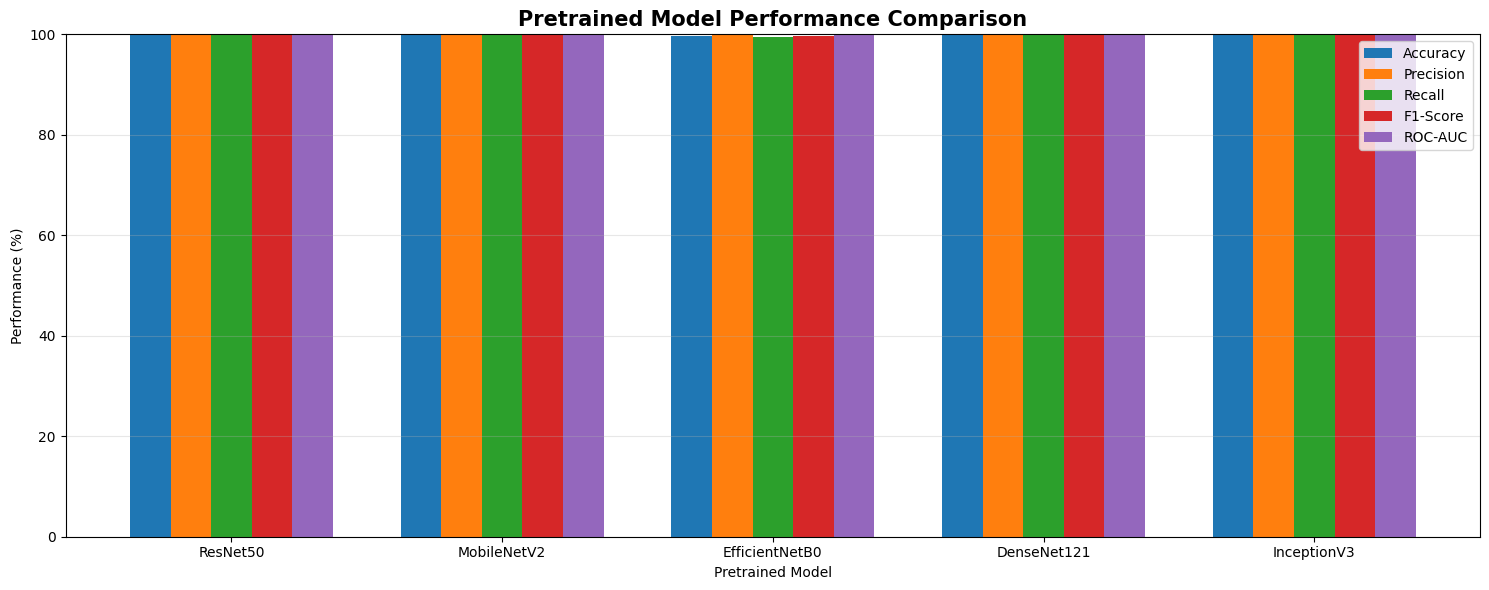

In [51]:
# ==========================================
# PERFORMANCE BAR CHART - ALL 5 MODELS
# ==========================================

metrics = [
    "Accuracy (%)",
    "Precision (%)",
    "Recall (%)",
    "F1-Score (%)",
    "ROC-AUC (%)"
]

x = np.arange(len(results_df))
width = 0.15

plt.figure(figsize=(15, 6))

for i, metric in enumerate(metrics):

    plt.bar(
        x + (i - 2) * width,
        results_df[metric],
        width,
        label=metric.replace(" (%)", "")
    )

plt.xticks(
    x,
    results_df["Model"]
)

plt.xlabel("Pretrained Model")
plt.ylabel("Performance (%)")

plt.title(
    "Pretrained Model Performance Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.ylim(0, 100)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

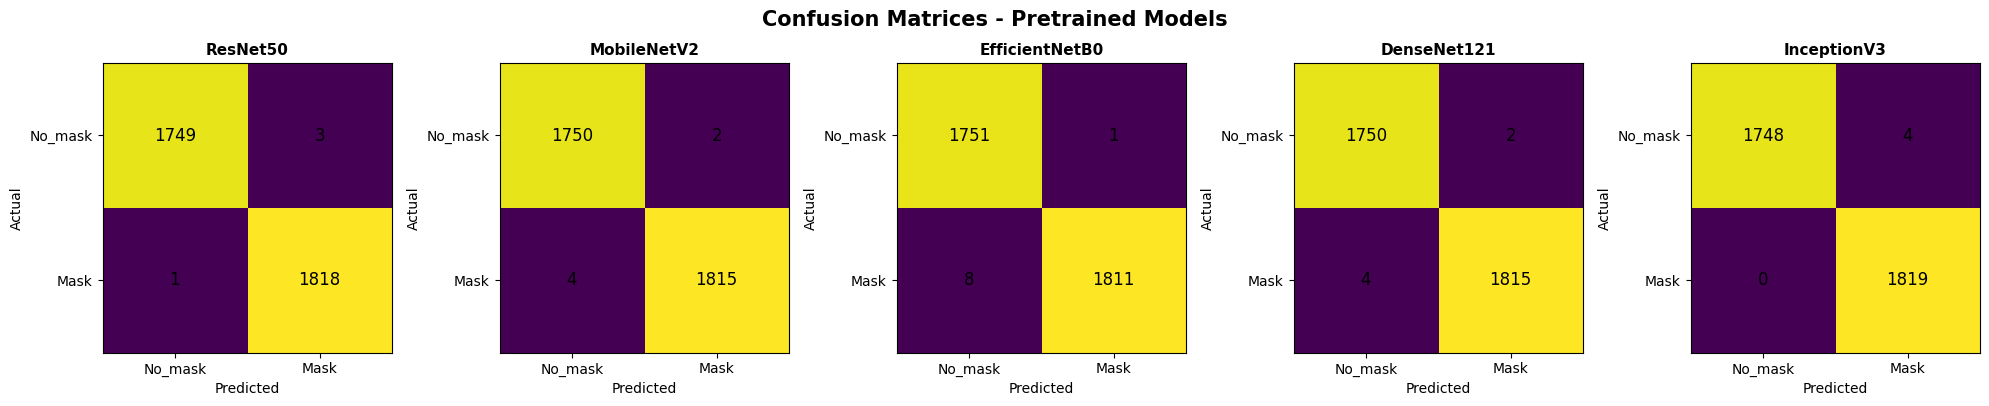

In [52]:
# ==========================================
# CONFUSION MATRICES - ALL 5 MODELS
# ==========================================

fig, axes = plt.subplots(
    1,
    5,
    figsize=(20, 4)
)

for ax, (name, model, dataset) in zip(
    axes,
    model_info
):

    y_prob = model.predict(
        dataset,
        verbose=0
    ).reshape(-1)

    y_pred = (y_prob >= 0.5).astype(int)

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    ax.imshow(cm)

    ax.set_title(
        name,
        fontsize=11,
        fontweight="bold"
    )

    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    ax.set_xticklabels([
        "No_mask",
        "Mask"
    ])

    ax.set_yticklabels([
        "No_mask",
        "Mask"
    ])

    for i in range(2):
        for j in range(2):

            ax.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center",
                fontsize=12
            )

plt.suptitle(
    "Confusion Matrices - Pretrained Models",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()